# Термодинамика вырожденных праймеров

Используем NN-модель термодинамики ДНК-дуплексов (SantaLucia, 1998), расчет проведем через primer3-py.

Для каждого праймера нужно развернуть вырожденные позиции в набор невырожденных
последовательностей. Далее необходимо рассчитать для каждого варианта Tm и ΔG дуплекса, шпильки и гомодимера,
и вывести статистику (среднее, медиана, 5% и 95% перцентили) отдельно по каждому праймеру и по всей выборке.

In [3]:
!pip install -q primer3-py biopython pandas numpy matplotlib

In [20]:
# добавляем user-site в sys.path: в этом окружении conda не подключает его по умолчанию
import sys, site
path = site.getusersitepackages()
if path not in sys.path:
    sys.path.insert(0, path)

In [21]:
import itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq
import primer3

## 1. Разворачиваем вырожденные позиции

Каждая буква IUPAC кодирует набор возможных нуклеотидов. Чтобы получить
все невырожденные варианты последовательности, нужно взять декартово произведение множеств по всем позициям.

In [22]:
IUPAC_CODES = {
    "A": "A", "C": "C", "G": "G", "T": "T",
    "R": "AG", "Y": "CT", "S": "GC", "W": "AT", "K": "GT", "M": "AC",
    "B": "CGT", "D": "AGT", "H": "ACT", "V": "ACG",
    "N": "ACGT",
}

def expand_degenerate(seq: str) -> list[str]:
    seq = seq.upper()
    variants_per_pos = [IUPAC_CODES[base] for base in seq]
    return ["".join(combo) for combo in itertools.product(*variants_per_pos)]

def n_variants(seq: str) -> int:
    seq = seq.upper()
    n = 1
    for base in seq:
        n *= len(IUPAC_CODES[base])
    return n

## 2. Считаем термодинамику одной невырожденной последовательности

Для каждого варианта:
- дуплекс праймер : комплементарная мишень (Tm, ΔG)
- шпилька самого праймера (Tm, ΔG)
- гомодимер — способность праймера образовывать дуплекс сам с собой (Tm, ΔG)

Условия реакции единые для всех расчётов, типичные для ПЦР.

Tm и ΔG дуплекса рассчитываем через calc_heterodimer. Эта функция использует ту же NN-модель, что и calc_tm, но дополнительно возвращает ΔG, которая отдельной функцией calc_tm не считается.

In [7]:
THERMO_PARAMS = dict(
    mv_conc=50.0,     # моновалентные катионы, мМ
    dv_conc=1.5,      # двухвалентные катионы (Mg2+), мМ
    dntp_conc=0.2,    # dNTP, мМ
    dna_conc=250.0,   # концентрация олигонуклеотида, нМ
    temp_c=37.0,      # температура расчёта ΔG структур, °C
)

In [8]:
def analyze_sequence(seq: str) -> dict:
    rc = str(Seq(seq).reverse_complement())

    duplex = primer3.calc_heterodimer(seq, rc, **THERMO_PARAMS)      # праймер : комплементарная мишень
    hairpin = primer3.calc_hairpin(seq, **THERMO_PARAMS)
    homodimer = primer3.calc_homodimer(seq, **THERMO_PARAMS)

    return {
        "sequence": seq,
        "tm_duplex_C": duplex.tm,
        "dg_duplex_kcal_mol": duplex.dg / 1000,
        "hairpin_found": hairpin.structure_found,
        "tm_hairpin_C": hairpin.tm if hairpin.structure_found else np.nan,
        "dg_hairpin_kcal_mol": hairpin.dg / 1000 if hairpin.structure_found else np.nan,
        "homodimer_found": homodimer.structure_found,
        "tm_homodimer_C": homodimer.tm if homodimer.structure_found else np.nan,
        "dg_homodimer_kcal_mol": homodimer.dg / 1000 if homodimer.structure_found else np.nan,
    }

## 3. Загружаем праймеры, чтобы оценить их количество

In [9]:
FASTA_PATH = "primers_test.fasta"   # путь к загруженному файлу
RANDOM_SEED = 42
MAX_VARIANTS_PER_PRIMER = None      # None — полный перебор; либо целое число для случайной подвыборки

primers = {rec.id: str(rec.seq) for rec in SeqIO.parse(FASTA_PATH, "fasta")}

overview = pd.DataFrame({
    "primer_id": list(primers.keys()),
    "sequence": list(primers.values()),
    "length": [len(s) for s in primers.values()],
    "n_degenerate_positions": [sum(1 for b in s if len(IUPAC_CODES[b.upper()]) > 1) for s in primers.values()],
    "n_variants": [n_variants(s) for s in primers.values()],
})
overview

,primer_id,sequence,length,n_degenerate_positions,n_variants
0,pr_1,TTCCTCTGTCATGCCTTGG,19,0,1
1,pr_2,STCCAHGCBARMACRAANG,19,7,576
2,pr_3,GRTTKGGSYGYYTCHBRTCG,20,9,1152
3,pr_4,TCRTTYGWCCARCAHARNYKDC,22,10,4608
4,pr_5,GVGTRKTRCTRCTDATNGTDG,21,8,1728
5,pr_6,GCNTYRTCMGGRCARYRRC,19,9,1024
6,pr_7,CCANASBCKVGTRWANANWTC,21,10,18432
7,pr_8,CKYTGYCCNGTSARBYBNYG,20,11,18432


In [10]:
print(f"Суммарное число невырожденных структур во всём наборе: {overview['n_variants'].sum():,}")

Суммарное число невырожденных структур во всём наборе: 45,953


## 4. Считаем термодинамику для всех невырожденных вариантов

Для каждого праймера разворачиваем все варианты и прогоняем через analyze_sequence.

In [11]:
rng = np.random.default_rng(RANDOM_SEED)
records = []

for primer_id, seq in primers.items():
    variants = expand_degenerate(seq)
    if MAX_VARIANTS_PER_PRIMER is not None and len(variants) > MAX_VARIANTS_PER_PRIMER:
        idx = rng.choice(len(variants), size=MAX_VARIANTS_PER_PRIMER, replace=False)
        variants = [variants[i] for i in idx]

    for v in variants:
        row = analyze_sequence(v)
        row["primer_id"] = primer_id
        records.append(row)

results = pd.DataFrame.from_records(records)
results = results[[
    "primer_id", "sequence",
    "tm_duplex_C", "dg_duplex_kcal_mol",
    "hairpin_found", "tm_hairpin_C", "dg_hairpin_kcal_mol",
    "homodimer_found", "tm_homodimer_C", "dg_homodimer_kcal_mol",
]]
results.head()

,primer_id,sequence,tm_duplex_C,dg_duplex_kcal_mol,hairpin_found,tm_hairpin_C,dg_hairpin_kcal_mol,homodimer_found,tm_homodimer_C,dg_homodimer_kcal_mol
0,pr_1,TTCCTCTGTCATGCCTTGG,60.048090,-20.239899,False,NaN,NaN,True,-19.616938,-2.675804
1,pr_2,GTCCAAGCCAAAACAAAAG,56.094785,-18.749114,False,NaN,NaN,True,-47.726331,-1.879791
2,pr_2,GTCCAAGCCAAAACAAACG,58.728690,-20.064154,False,NaN,NaN,True,-44.706226,-1.997461
3,pr_2,GTCCAAGCCAAAACAAAGG,58.024791,-19.562459,False,NaN,NaN,True,-47.726331,-1.879791
4,pr_2,GTCCAAGCCAAAACAAATG,56.168544,-18.780129,False,NaN,NaN,True,-47.726331,-1.879791


## 5. Считаем статистику

Для Tm и ΔG каждой из трех структур нужно рассчитать среднее, медиану, 5-й и 95-й перцентили.

Для шпильки и гомодимера статистику считаем только по вариантам, где структура вообще была найдена
(hairpin_found / homodimer_found = True), и отдельно приводим долю таких вариантов.

In [12]:
PARAMS = [
    "tm_duplex_C", "dg_duplex_kcal_mol",
    "tm_hairpin_C", "dg_hairpin_kcal_mol",
    "tm_homodimer_C", "dg_homodimer_kcal_mol",
]

def describe_stats(df: pd.DataFrame) -> pd.Series:
    """Среднее, медиана, 5-й и 95-й перцентили по каждому параметру."""
    out = {}
    for p in PARAMS:
        vals = df[p].dropna()
        out[(p, "mean")] = vals.mean()
        out[(p, "median")] = vals.median()
        out[(p, "p05")] = np.percentile(vals, 5) if len(vals) else np.nan
        out[(p, "p95")] = np.percentile(vals, 95) if len(vals) else np.nan
    out[("n_variants", "")] = len(df)
    out[("hairpin_rate", "")] = df["hairpin_found"].mean()
    out[("homodimer_rate", "")] = df["homodimer_found"].mean()
    return pd.Series(out)

In [14]:
per_primer_stats = results.groupby("primer_id", sort=False).apply(describe_stats, include_groups=False)
per_primer_stats.columns = pd.MultiIndex.from_tuples(per_primer_stats.columns)
per_primer_stats

tm_duplex_C                                  dg_duplex_kcal_mol  \
                 mean     median        p05        p95               mean   
primer_id                                                                   
pr_1        60.048090  60.048090  60.048090  60.048090         -20.239899   
pr_2        59.850743  59.870750  54.969605  64.646237         -20.599054   
pr_3        64.228219  64.293477  59.127567  69.048248         -23.107807   
pr_4        62.415882  62.280805  57.361667  67.613483         -23.314912   
pr_5        58.487816  58.524591  52.343273  64.593519         -20.789569   
pr_6        63.154046  63.089040  56.779274  69.450229         -22.067490   
pr_7        58.695808  58.766942  53.044784  63.948034         -20.886201   
pr_8        64.914172  64.729136  58.979822  71.248551         -23.515225   

                                           tm_hairpin_C             ...  \
              median        p05        p95         mean     median  ...   
primer_id                                                           ...   
pr_1      -20.239899 -20.239899 -20.239899          NaN        NaN  ...   
pr_2      -20.579379 -23.003254 -18.252733    39.598056  36.917119  ...   
pr_3      -23.097218 -25.536035 -20.588850    41.968912  36.541011  ...   
pr_4      -23.278853 -26.202163 -20.635243    44.470264  46.113434  ...   
pr_5      -20.765241 -23.941279 -17.600201    42.901945  41.982962  ...   
pr_6      -21.950994 -25.186714 -19.081586    44.648971  44.176451  ...   
pr_7      -20.907721 -23.657536 -18.028021    43.205487  41.206816  ...   
pr_8      -23.469680 -26.649945 -20.540165    44.637580  42.730853  ...   

          tm_homodimer_C                       dg_homodimer_kcal_mol  \
                  median        p05        p95                  mean   
primer_id                                                              
pr_1          -19.616938 -19.616938 -19.616938             -2.675804   
pr_2          -22.415378 -41.194063  23.682504             -4.258465   
pr_3            1.308038 -35.478080  33.512512             -4.395396   
pr_4          -17.879540 -40.728075  22.250839             -3.496567   
pr_5            4.696328 -28.074197  30.066036             -4.112305   
pr_6           12.423671 -26.697459  42.755169             -5.766591   
pr_7            8.937843 -36.434161  41.133426             -5.008819   
pr_8            1.801210 -41.252235  27.456193             -4.077296   

                                         n_variants hairpin_rate  \
             median        p05       p95                           
primer_id                                                          
pr_1      -2.675804  -2.675804 -2.675804        1.0     0.000000   
pr_2      -3.778291  -7.791604 -2.335431      576.0     0.246528   
pr_3      -4.501754  -9.493637 -1.443257     1152.0     0.392361   
pr_4      -2.876544  -6.320958 -1.818768     4608.0     0.707031   
pr_5      -4.113689  -8.188487 -2.002657     1728.0     0.496528   
pr_6      -5.369044 -12.111026 -2.194461     1024.0     0.735352   
pr_7      -4.463842 -11.127599 -1.917391    18432.0     0.420410   
pr_8      -3.618956  -7.806189 -1.662881    18432.0     0.485243   

          homodimer_rate  
                          
primer_id                 
pr_1                 1.0  
pr_2                 1.0  
pr_3                 1.0  
pr_4                 1.0  
pr_5                 1.0  
pr_6                 1.0  
pr_7                 1.0  
pr_8                 1.0  

[8 rows x 27 columns]

In [18]:
overall_stats = describe_stats(results)
overall_stats

tm_duplex_C            mean         61.807786
                       median       61.725481
                       p05          54.500299
                       p95          69.191215
dg_duplex_kcal_mol     mean        -22.259029
                       median      -22.221826
                       p05         -25.789045
                       p95         -18.686291
tm_hairpin_C           mean         43.958538
                       median       42.458884
                       p05          33.807406
                       p95          57.801226
dg_hairpin_kcal_mol    mean         -0.593465
                       median       -0.387685
                       p05          -1.805061
                       p95           0.243378
tm_homodimer_C         mean         -1.970935
                       median        2.501469
                       p05         -41.252235
                       p95          32.291567
dg_homodimer_kcal_mol  mean         -4.441877
                       median     

## 6. Смотрим на распределения

Строим боксплоты по каждому параметру, разбитые по праймерам. Так виден разброс термодинамики
внутри каждой вырожденной структуры, можно сравнить праймеры между собой.

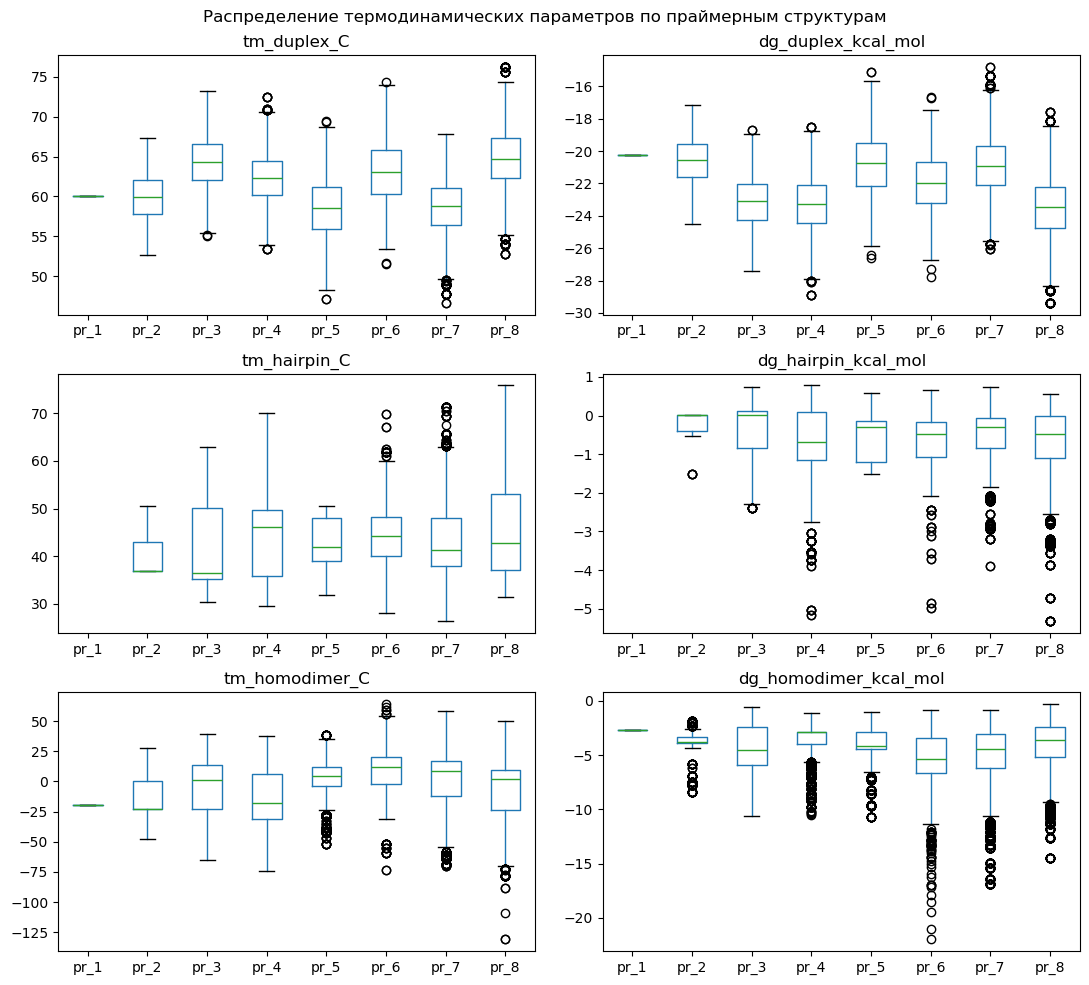

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(11, 10))
for ax, p in zip(axes.ravel(), PARAMS):
    results.boxplot(column=p, by="primer_id", ax=ax, grid=False)
    ax.set_title(p)
    ax.set_xlabel("")
plt.suptitle("Распределение термодинамических параметров по праймерным структурам")
plt.tight_layout()
plt.show()

## 7. Сохраняем результаты

Записываем полную таблицу по всем вариантам и обе статистики (по праймерам и по всей выборке) в csv.

In [24]:
# для per_primer_stats: превращаем мультииндекс колонок в плоские понятные названия
per_primer_flat = per_primer_stats.copy()
per_primer_flat.columns = [
    f"{param}_{stat}" if stat else param
    for param, stat in per_primer_flat.columns
]
per_primer_flat = per_primer_flat.round(3)

# для overall_stats: превращаем Series в аккуратную таблицу с понятными колонками
overall_flat = overall_stats.reset_index()
overall_flat.columns = ["parameter", "statistic", "value"]
overall_flat["value"] = overall_flat["value"].round(3)

results.to_csv("primer_thermodynamics_full.csv", index=False)
per_primer_flat.to_csv("primer_thermodynamics_stats_per_primer.csv")
overall_flat.to_csv("primer_thermodynamics_stats_overall.csv", index=False)

print("Сохранены файлы:")
print(" - primer_thermodynamics_full.csv")
print(" - primer_thermodynamics_stats_per_primer.csv")
print(" - primer_thermodynamics_stats_overall.csv")

Сохранены файлы:
 - primer_thermodynamics_full.csv
 - primer_thermodynamics_stats_per_primer.csv
 - primer_thermodynamics_stats_overall.csv


In [25]:
with pd.ExcelWriter("primer_thermodynamics_results.xlsx") as writer:
    overview.to_excel(writer, sheet_name="primers_overview", index=False)
    results.to_excel(writer, sheet_name="full_results", index=False)
    per_primer_flat.to_excel(writer, sheet_name="stats_per_primer")
    overall_flat.to_excel(writer, sheet_name="stats_overall", index=False)

print("Сохранён файл primer_thermodynamics_results.xlsx")

Сохранён файл primer_thermodynamics_results.xlsx


## Выводы

Полный набор из 45953 невырожденных вариантов восьми праймеров был проанализирован по шести
термодинамическим параметрам. Tm дуплекса праймер:мишень для большинства структур лежит
в диапазоне 55-70°C, что соответствует типичным условиям отжига в ПЦР. Гомодимерные структуры
обнаруживаются практически для всех вариантов (homodimer_rate ≈ 1.0), тогда как устойчивые
шпильки формируются заметно реже и зависят от конкретного праймера (hairpin_rate от 0 до 0.7).
Наибольший разброс термодинамических параметров внутри одной вырожденной структуры наблюдается
у праймеров с наибольшим числом вариантов (pr_7, pr_8), что ожидаемо при большем количестве
вырожденных позиций.